Biometrich Technologies and Behavioural Security
# **<center>Tutorial - Face Recognition</center>**
## **<center>Part 2: The textural descriptor LBP</center>**



## Step 1: Load data and packages in your VM

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
import numpy as np
import cv2


## Step 2: LBP method definition

Run the cell to define a function named **lbp_calculated_pixel**, that takes as argument:

*   The image to be processed.
*   x and y coordinates of image's pixel.

In [ ]:
def get_pixel(img, center, x, y):
    new_value = 0
    try:
        if img[x][y] >= center:
            new_value = 1
    except:
        pass
    return new_value

def lbp_calculated_pixel(img, x, y):

    center = img[x][y]
    val_ar = []
    val_ar.append(get_pixel(img, center, x-1, y+1))     # top_right
    val_ar.append(get_pixel(img, center, x, y+1))       # right
    val_ar.append(get_pixel(img, center, x+1, y+1))     # bottom_right
    val_ar.append(get_pixel(img, center, x+1, y))       # bottom
    val_ar.append(get_pixel(img, center, x+1, y-1))     # bottom_left
    val_ar.append(get_pixel(img, center, x, y-1))       # left
    val_ar.append(get_pixel(img, center, x-1, y-1))     # top_left
    val_ar.append(get_pixel(img, center, x-1, y))       # top

    power_val = [1, 2, 4, 8, 16, 32, 64, 128]
    val = 0
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
    return val

In [ ]:
# Load data
lfw_dataset = fetch_lfw_people(min_faces_per_person=100)

_, h, w = lfw_dataset.images.shape
X = lfw_dataset.data
label = lfw_dataset.target
target_names = lfw_dataset.target_names



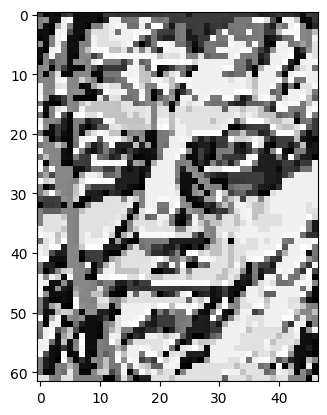

In [ ]:
data=[]
for image in X:
  image=image.reshape((h, w))
  height, width = image.shape

  img_lbp = np.zeros((height, width,3), np.uint8)
  for i in range(0, height):
      for j in range(0, width):
            img_lbp[i, j] = lbp_calculated_pixel(image, i, j)
  hist_lbp = cv2.calcHist([img_lbp], [0], None, [256], [0, 256])
  hist_lbp = hist_lbp.astype("float")
  hist_lbp /= (hist_lbp.sum() + 1e-7)
  data.append(hist_lbp)
plt.figure()
plt.imshow(img_lbp)

In [ ]:
#Split data array in train and test data for SVM

from sklearn.model_selection import train_test_split
data = np.array(data)[:,:,0]
label = np.array(label)
print(np.shape(data))
print(np.shape(label))

X_train,X_test,y_train,y_test = train_test_split(data,label,test_size = 0.2)

(1140, 256)
(1140,)


We use this time LinearSVC, similar to SVC with parameter kernel=’linear’, but implemented in terms of liblinear rather than libsvm, so it has more flexibility in the choice of penalties and loss functions and should scale better to large numbers of samples.

In [ ]:
#Train the SVM classifier

from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(X_train, y_train)

LinearSVC(random_state=0, tol=1e-05)

In [ ]:
#Predict test labels and accuracy

y_pred = clf.predict(X_test)
from sklearn.metrics import accuracy_score
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_test, y_pred)*100)
print(acc)
np.unique(label)

Total Accuracy: 50.88 %


array([0, 1, 2, 3, 4])



```
# Extended LBP
```



In [ ]:
from skimage import feature
numPoints=8
radius=2
def describe( image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, numPoints,
			radius, method="uniform")
		#construct the actual feature vector
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, numPoints + 3),
			range=(0, numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return lbp, hist

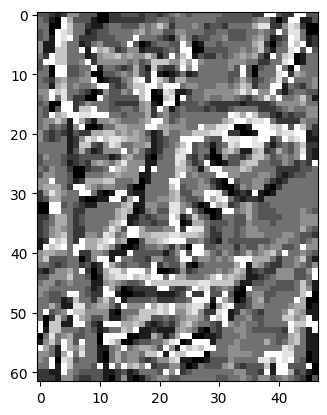

In [ ]:
data=[]
for image in X:
  image=image.reshape((h, w))
  lbp , hist = describe(image)
  data.append(hist)
plt.figure()
plt.imshow(lbp, cmap="gray")

In [ ]:
print(data[0])

[0.05147563 0.07961565 0.08991078 0.148593   0.2240906  0.12457104
 0.05078929 0.06657515 0.040151   0.12422787]


In [ ]:
#Split data array in train and test data for SVM

from sklearn.model_selection import train_test_split
label = np.array(label)
print(np.shape(data))
print(np.shape(label))

X_train,X_test,y_train,y_test = train_test_split(data,label,test_size = 0.2)

(1140, 10)
(1140,)


In [ ]:
#Train the SVM classifier

from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(X_train, y_train)

LinearSVC(random_state=0, tol=1e-05)

In [ ]:
#Predict test labels and accuracy

y_pred = clf.predict(X_test)
from sklearn.metrics import accuracy_score
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_test, y_pred)*100)
print(acc)

Total Accuracy: 50.88 %
